# Project 3

## 1. Objectives

The purpose of this assignment is to train, validate, and tune multi-class ordinal classification models that can predict a survey respondent’s current yearly compensation bucket, based on a set of survey responses by a data scientist. The following sections should be included but the order does not need to be followed.

Import relevant libraries:

In [1]:
import pandas as pd
import numpy as np
import re
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, confusion_matrix
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
%matplotlib inline

Print the version of Python:

In [2]:
from pathlib import Path
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


Load the project files:

In [3]:
!git clone https://github.com/ali-sh-96/Machine-learning-Portfolio.git

# Get the path to the installed package.
root_dir = Path("Machine-learning-Portfolio")

# Select project
project_name = "project3"
project_dir = root_dir / project_name

Cloning into 'Machine-learning-Portfolio'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 114 (delta 40), reused 63 (delta 24), pack-reused 32 (from 1)
Receiving objects: 100% (114/114), 81.09 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Updating files: 100% (29/29), done.


Importing the data:

In [4]:
df = pd.read_csv(project_dir / "clean_kaggle_data_2022.csv", encoding='ISO-8859-1', low_memory=False)
df.shape

(8137, 298)

We drop the first column (time spent for completing the survay) since this column is not a feature. We also drop the first row as it does not contain any data.

In [5]:
df.drop(index=0, inplace=True)
df = df.reset_index().drop(columns=['index', 'Duration (in seconds)'])
df.shape

(8136, 297)

## 2. Data Cleaning

While the data is made ready for analysis, several values are missing, and some features are categorical. Note that some values that appear “null” indicate that a survey respondent did not select that given option from a multiple-choice list. For example – “Which of the following hosted notebook products do you use on a regular basis? (Select all that apply) - Selected Choice - Binder / JupyterHub”.

For the data cleaning step, we handle missing values however we see fit and justify our approach. Additionally, we provide some insight on why we think the values are missing and how our approach might impact the overall analysis. Suggestions include filling the missing values with a certain value (e.g., mode for categorical data) and completely removing the features with missing values. Another method could be filling them with a separate value showing missingness, e.g., “unknown”. Secondly, we convert categorical data into numerical data by encoding and explain why we use this particular encoding method.

These tasks can be done interchangeably, e.g., encoding can be done first.

Our project includes the following:

- Data cleaning code that handles missing values and categorical features (with proper justification; discarding part of the features is acceptable as well)
- Explanation about each of our data cleaning steps and justification of our approach

Checking how many null values there are in single columns Q2-Q5, Q8, Q9, Q11, Q16, Q22-Q27, Q29, Q30, Q32, Q43:

In [6]:
Qs = [2, 3, 4, 5, 8, 9, 11, 16, 22, 23, 24, 25, 26, 27, 29, 30, 32, 43]
na = df[['Q'+str(i) for i in Qs]].isnull()
na.sum(axis=0)

,0
Q2,0
Q3,0
Q4,0
Q5,0
Q8,0
Q9,2941
Q11,0
Q16,684
Q22,6522
Q23,0


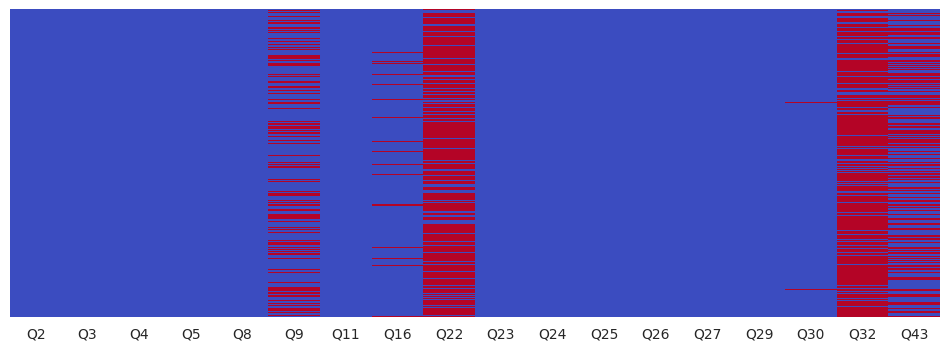

In [7]:
fig, ax = plt.subplots(figsize=(12,4))
sns.heatmap(na, cmap='coolwarm', yticklabels=False, cbar=False, ax=ax)
plt.show()

Next, we check how many null values there are in for columns with dummy features Q6, Q7, Q10, Q12-Q15, Q17-Q21, Q28, Q31, Q33-Q42, and Q44. For these columns, dummy features are readily available in the data file. The response to a question is null only when all dummy features are null.

In [8]:
Qs = [6, 7, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44]
num = [13, 8, 4, 16, 15, 17, 16, 16, 15, 9, 7, 11, 9, 13, 6, 9, 17, 16, 14, 9, 13, 16, 10, 10, 13]
null = [None]*len(Qs)
na = pd.DataFrame(index=df.index, columns=['Q'+str(i) for i in Qs]).notnull()
for j in range(len(Qs)):
    dummies = df[['Q'+str(Qs[j])+'_'+str(i) for i in range(1,num[j])]]
    null[j] = dummies.index[dummies.isnull().sum(axis=1)==num[j]-1].tolist()
    na.loc[null[j], 'Q'+str(Qs[j])] = True
na.sum(axis=0)

,0
Q6,805
Q7,1
Q10,5464
Q12,804
Q13,963
Q14,3180
Q15,1899
Q17,2293
Q18,2187
Q19,5973


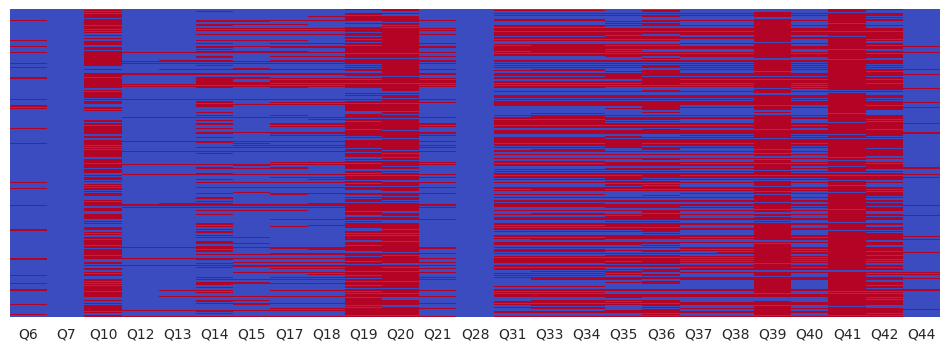

In [9]:
fig, ax = plt.subplots(figsize=(12,4))
sns.heatmap(na, cmap='coolwarm', yticklabels=False, cbar=False, ax=ax)
plt.show()

First, let us deal with null values in **Q9** column. Based on `kaggle_survey_2022_answer_choices.pdf`, Q9 is only asked if Q8 > Bachelor's. The unique values of Q8 are as follows:

In [10]:
labels = df['Q8'].unique()
labels

array(['Some college/university study without earning a bachelor\x81E\x80\x81Es degree',
       'Bachelor\x81E\x80\x81Es degree', 'Doctoral degree',
       'Master\x81E\x80\x81Es degree', 'I prefer not to answer',
       'No formal education past high school', 'Professional doctorate'],
      dtype=object)

In [11]:
encs = ["Some college/university study without earning a bachelor's degree", "Bachelor's degree", 'Doctoral degree',
        "Master's degree", 'I prefer not to answer', 'No formal education past high school', 'Professional doctorate']
mapping = dict(zip(labels, encs))
df.replace({'Q8': mapping}, inplace=True)

In [12]:
idx = (df['Q8'] == "Bachelor's degree") | (df['Q8'] == "Some college/university study without earning a bachelor's degree") | \
(df['Q8'] == 'No formal education past high school') | (df['Q8'] == 'I prefer not to answer')
len(df.loc[idx, 'Q9'])

2941

It is already clear that all 2941 out of 2941 null values are due to the survay methodology, that is people with highest level of formal education lower than `Master's degree` or those who answered `I prefered not to answer` were not asked whether they have any publications or not.

Now lets Let's check if there is a pattern as to how null values appear. We compare the distribution of highest formal education and highest formal education where publication is null:

In [13]:
a = df['Q8'].value_counts(normalize=True)
b = df[df['Q9'].isnull()]['Q8'].value_counts(normalize=True)
print(pd.DataFrame({'All': a, 'Null':b}))

                                                         All      Null
Q8                                                                    
Bachelor's degree                                   0.246436  0.681741
Doctoral degree                                     0.165806       NaN
I prefer not to answer                              0.052360  0.144849
Master's degree                                     0.438422       NaN
No formal education past high school                0.025320  0.070044
Professional doctorate                              0.034292       NaN
Some college/university study without earning a...  0.037365  0.103366


As mentioned previously, there is a higher proportion of education degrees in Bachelor's degree and lower education levels where the publication is null. The plot below also shows the distribution of publications among groups who were asked the question. Based on this plot we can infer that a lower education level does not necessarily mean no publications. Therefore, we fill the null values in Q9 with a filler `'Unknown'` variable.

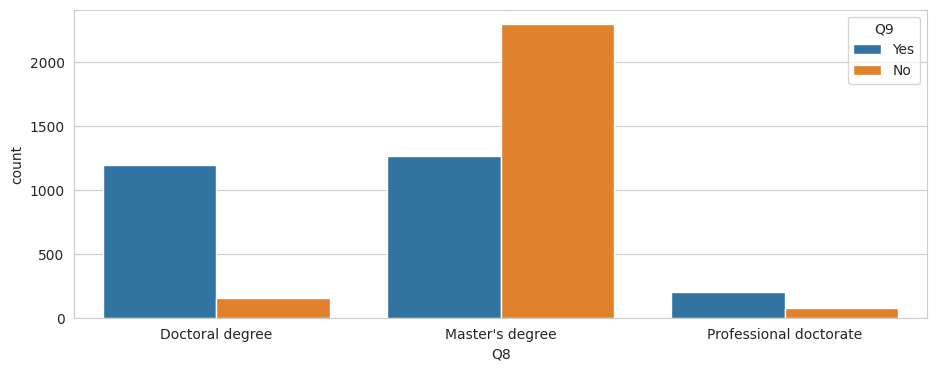

In [14]:
fig, ax = plt.subplots(figsize=(11,4))
data = df[(df['Q8'] == "Master's degree") | (df['Q8'] == 'Doctoral degree') | (df['Q8'] == 'Professional doctorate')]
sns.countplot(x='Q8', hue='Q9', data=data)
plt.show()

Based on `kaggle_survey_2022_answer_choices.pdf`, **Q10** is only asked if Q9 is `'Yes'`. The analysis below shows that all nulls are due to the survay methodology, that is there are no nulls where Q9 is `'Yes'`.

In [15]:
df.loc[df['Q9'].isnull(), 'Q9'] = 'Unknown'

In [16]:
len(na.loc[df['Q9'] == 'No', 'Q10'] == True)+2941

5464

For those who answered `'No'` to Q9, we can decisively say that the have not used ML in their research. For those who did not answer Q9, however, we do not even know if they have any publications. By a similar logic as Q9, we fill these null values with `'Unknown'`. Note that we need to add a dummy column for this new feature:

In [17]:
df.loc[df['Q9'] == 'No', 'Q10_3'] = 'No'
df.insert(loc = 28, column = 'Q10_4', value=np.nan)
df.loc[df['Q9'] == 'Unknown', 'Q10_4'] = 'Unknown'

/tmp/ipykernel_916/1645385086.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['Q9'] == 'Unknown', 'Q10_4'] = 'Unknown'


According to `kaggle_survey_2022_answer_choices.pdf`, **Q12** is only asked if Q11 > 0. The analysis below shows that all nulls are due to the survay methodology, that is all nulls belong to participants who answered `'I have never written code'`.

In [18]:
len(na.loc[df['Q11'] == 'I have never written code', 'Q12'] == True)

684

These null values must be replaced with `'None'` value from the list:

In [19]:
df.loc[na['Q12'] == True, 'Q12_14'] = 'None'

Similarly, **Q16** is only asked if Q11 > 0. Lets check if the null values in Q16 belong to participants who answered `'I have never written code'`:

In [20]:
len(df[df['Q11'] == 'I have never written code']['Q16'].isnull())

684

Hence, we can replace the null values in Q16 with `'I do not use machine learning methods'` since people who have never written code do not use machine learning methods.

In [21]:
df.loc[df['Q16'].isnull(), 'Q16'] = 'I do not use machine learning methods'

For **Q13**, **Q14**, and **Q15**, however, some null values do not correspond to participants who answered Q11 with `'I have never written code'` (804 > 684). First, we show that for these participants Q13, Q14, and Q15 are null, and consequently, some null values may be replaced with `'None'`, which is an answer choice for all three Q13, Q14, and Q15:

In [22]:
len(na[df['Q11'] == 'I have never written code']['Q13'] == True)

684

In [23]:
len(na[df['Q11'] == 'I have never written code']['Q14'] == True)

684

In [24]:
len(na[df['Q11'] == 'I have never written code']['Q15'] == True)

684

In [25]:
df.loc[df['Q11'] == 'I have never written code', 'Q13_13'] = 'None'
df.loc[df['Q11'] == 'I have never written code', 'Q14_15'] = 'None'
df.loc[df['Q11'] == 'I have never written code', 'Q15_14'] = 'None'

Furthermore, the rows containing null values for Q13, Q14, and Q15 are identical, that is participants who did not answer Q13, did not answer Q14 and Q15 either.

In [26]:
len(na.loc[na['Q13'] == True, 'Q14'])

963

In [27]:
len(na.loc[na['Q13'] == True, 'Q15'])

963

We replace the remaining 120 rows with `'other'`, which has the same role as `'Unknown'` filler and is a readily available answer choice:

In [28]:
df.loc[(df['Q11'] != 'I have never written code') & (na['Q13'] == True), 'Q13_14'] = 'Other'
df.loc[(df['Q11'] != 'I have never written code') & (na['Q13'] == True), 'Q14_16'] = 'Other'
df.loc[(df['Q11'] != 'I have never written code') & (na['Q13'] == True), 'Q15_15'] = 'Other'

Based on `kaggle_survey_2022_answer_choices.pdf`, **Q17**, **Q18**, and **Q21** are only asked if Q16 > 0. The analysis below shows that all nulls correspond to participants who answered `'I do not use machine learning methods'` to Q16:

In [29]:
idx = (df['Q16'] == 'I do not use machine learning methods')

In [30]:
len(na.loc[idx, 'Q17'])

1791

In [31]:
len(na.loc[idx, 'Q18'])

1791

In [32]:
len(na.loc[idx, 'Q21'])

1791

Hence, we replace the null values in Q17 and Q18 with `'None'`, and Q21 with `'No, I do not download pre-trained model weights on a regular basis'`:

In [33]:
df.loc[na['Q17'] == True, 'Q17_14'] = 'None'
df.loc[na['Q18'] == True, 'Q18_13'] = 'None'
df.loc[na['Q21'] == True, 'Q21_9'] = 'No, I do not download pre-trained model weights on a regular basis'

Q19 is answered if Q16 > 0 and Q18 = `'CNN'`, `'GAN'`, or `'Transformer'`:

In [34]:
idx = (df['Q16'] == 'I do not use machine learning methods') | \
((df['Q18_7'] != 'Convolutional Neural Networks') & (df['Q18_8'] != 'Generative Adversarial Networks') & \
 (df['Q18_10'] != 'Transformer Networks (BERT, gpt-3, etc)'))

In [35]:
len(na.loc[idx, 'Q19'])

5277

Again, we see that all null values belong to those who were not asked **Q19**. These participant did not use `'CNN'`, `'GAN'`, or `'Transformer'`, and consequently, we may choose `'None'` in Q19 answer choices.

In [36]:
df.loc[na['Q19'] == True, 'Q19_7'] = 'None'

We repeat the analysis for **Q20**, which is asked when Q16 > 0 and Q18 = `'RNN'` or `'Transformer'`:

In [37]:
idx = (df['Q16'] == 'I do not use machine learning methods') | \
((df['Q18_9'] != 'Recurrent Neural Networks') & (df['Q18_10'] != 'Transformer Networks (BERT, gpt-3, etc)'))

In [38]:
len(na.loc[idx, 'Q20'])

6133

All null values belong to those who were not asked Q20. These participant did not use `'RNN'` or `'Transformer'`, and consequently, we may fill the nulls in Q20 with `'None'`.

In [39]:
df.loc[na['Q20'] == True, 'Q20_5'] = 'None'

**Q30** is asked if Q5 = `'No'` and Q23 != `'unemployed'`, that is the participant is neither a student nor unemployed:

In [40]:
idx = (df['Q5'] != 'No') | (df['Q23'] == 'Currently not employed')

In [41]:
len(df.loc[idx, 'Q30'])

0

In this case the missing values are not due to methodology. Let's look at the distribution of jobs over all data and where Q30 is null:

In [42]:
a = df['Q23'].value_counts(normalize=True)
b = df[df['Q30'].isnull()]['Q23'].value_counts(normalize=True)
print(pd.DataFrame({'All': a, 'Null':b}))

                                                         All  Null
Q23                                                               
Data Administrator                                  0.008235  0.02
Data Analyst (Business, Marketing, Financial, Q...  0.166298  0.22
Data Architect                                      0.010079   NaN
Data Engineer                                       0.035275   NaN
Data Scientist                                      0.209931  0.18
Developer Advocate                                  0.006637  0.04
Engineer (non-software)                             0.050762  0.10
Machine Learning/ MLops Engineer                    0.062193  0.06
Manager (Program, Project, Operations, Executiv...  0.091691  0.02
Other                                               0.083825  0.06
Research Scientist                                  0.064528  0.12
Software Engineer                                   0.105580  0.10
Statistician                                        0.013274  

For most cases it Seems like there is no clear difference between the distributions. Hence, we fill the null values with the mode:

In [43]:
df['Q30'].fillna(df['Q30'].mode()[0],inplace=True)

/tmp/ipykernel_916/4087528747.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Q30'].fillna(df['Q30'].mode()[0],inplace=True)


**Q31**, **Q35**, and **Q36** are asked in case Q30 > 0:

In [44]:
idx = (df['Q30'] == '$0 ($USD)')

In [45]:
len(na.loc[idx, 'Q31'])

2703

In [46]:
len(na.loc[idx, 'Q35'])

2703

In [47]:
len(na.loc[idx, 'Q36'])

2703

Hence, 2703 out of 3082, 3146, and 3165 null values may be filled with `'None'`. We fill the rest of null values with `'Other'`:

In [48]:
df.loc[idx, 'Q31_11'] = 'None'
df.loc[idx, 'Q35_15'] = 'None'
df.loc[idx, 'Q36_14'] = 'None'

In [49]:
df.loc[(~idx) & (na['Q31'] == True), 'Q31_12'] = 'Other'
df.loc[(~idx) & (na['Q35'] == True), 'Q35_16'] = 'Other'
df.loc[(~idx) & (na['Q36'] == True), 'Q36_15'] = 'Other'

**Q33** and **Q34** are only asked when Q31 = `'AWS'`, `'Azure'`, or `'GCP'`:

In [50]:
idx = (df['Q31_1'] != ' Amazon Web Services (AWS) ') & (df['Q31_2'] != ' Microsoft Azure ') & \
(df['Q31_3'] != ' Google Cloud Platform (GCP) ')

In [51]:
len(na.loc[idx, 'Q33'])

4514

In [52]:
len(na.loc[idx, 'Q34'])

4514

Hence, for Q33 and Q34, 4514 out of 4533 and 4547 null values should be filled with `'No / None'`, while the rest can be filled with `'Other'`:

In [53]:
df.loc[idx, 'Q33_4'] = 'No / None'
df.loc[idx, 'Q34_7'] = 'No / None'

In [54]:
df.loc[(~idx) & (na['Q33'] == True), 'Q33_5'] = 'Other'
df.loc[(~idx) & (na['Q34'] == True), 'Q34_8'] = 'Other'

As for **Q37**, **Q38**, **Q39**, **Q40**, **Q41**, **Q42**, and **Q43**, these questions are asked if Q30 > 0 and Q16 > 0:

In [55]:
idx = ((df['Q30'] == '$0 ($USD)') | (df['Q16'] == 'I do not use machine learning methods'))

In [56]:
len(na.loc[idx, 'Q37'])

3546

In [57]:
len(na.loc[idx, 'Q38'])

3546

In [58]:
len(na.loc[idx, 'Q39'])

3546

In [59]:
len(na.loc[idx, 'Q40'])

3546

In [60]:
len(na.loc[idx, 'Q41'])

3546

In [61]:
len(na.loc[idx, 'Q42'])

3546

In [62]:
len(df.loc[idx, 'Q43'])

3546

We can fill 3546 out of 3649, 3666, 3679, 3696, 3704, 3714, and 3723 null values with proper answer choices from Q37, Q38, Q39, Q40, Q41, Q42, and Q43. We can fill the remaining null values with `'Other'` if it is an answer choice:

In [63]:
df.loc[idx, 'Q37_12'] = 'No / None'
df.loc[idx, 'Q38_7'] = 'No / None'
df.loc[idx, 'Q39_11'] = 'None'
df.loc[idx, 'Q40_14'] = 'No / None'
df.loc[idx, 'Q41_8'] = 'None'
df.loc[idx, 'Q42_8'] = 'None'
df.loc[idx, 'Q43'] = 'Never'

In [64]:
df.loc[(~idx) & (na['Q37'] == True), 'Q37_13'] = 'Other'
df.loc[(~idx) & (na['Q38'] == True), 'Q38_8'] = 'Other'
df.loc[(~idx) & (na['Q39'] == True), 'Q39_12'] = 'Other'
df.loc[(~idx) & (na['Q40'] == True), 'Q40_15'] = 'Other'
df.loc[(~idx) & (na['Q41'] == True), 'Q41_9'] = 'Other'
df.loc[(~idx) & (na['Q42'] == True), 'Q42_9'] = 'Other'

For Q43, however, `'Other'` is not an answer choice. Let's look at the distribution of jobs over all data and where Q43 is null:

In [65]:
a = df['Q23'].value_counts(normalize=True)
b = df[df['Q43'].isnull()]['Q23'].value_counts(normalize=True)
print(pd.DataFrame({'All': a, 'Null':b}))

                                                         All      Null
Q23                                                                   
Data Administrator                                  0.008235  0.011299
Data Analyst (Business, Marketing, Financial, Q...  0.166298  0.192090
Data Architect                                      0.010079  0.033898
Data Engineer                                       0.035275  0.005650
Data Scientist                                      0.209931  0.237288
Developer Advocate                                  0.006637  0.005650
Engineer (non-software)                             0.050762  0.050847
Machine Learning/ MLops Engineer                    0.062193  0.073446
Manager (Program, Project, Operations, Executiv...  0.091691  0.073446
Other                                               0.083825  0.033898
Research Scientist                                  0.064528  0.056497
Software Engineer                                   0.105580  0.084746
Statis

For most cases it Seems like there is no clear difference between the distributions. Hence, we fill the null values with the mode:

In [66]:
df['Q43'].fillna(df['Q43'].mode()[0],inplace=True)

/tmp/ipykernel_916/1754211954.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Q43'].fillna(df['Q43'].mode()[0],inplace=True)


For **Q44**, there are 284 null values. Again, we look at the distribution of jobs over all data and where Q44 is null:

In [67]:
a = df['Q23'].value_counts(normalize=True)
b = df[na['Q44'] == True]['Q23'].value_counts(normalize=True)
print(pd.DataFrame({'All': a, 'Null':b}))

                                                         All      Null
Q23                                                                   
Data Administrator                                  0.008235  0.017417
Data Analyst (Business, Marketing, Financial, Q...  0.166298  0.181422
Data Architect                                      0.010079  0.014514
Data Engineer                                       0.035275  0.011611
Data Scientist                                      0.209931  0.155298
Developer Advocate                                  0.006637  0.010160
Engineer (non-software)                             0.050762  0.068215
Machine Learning/ MLops Engineer                    0.062193  0.039187
Manager (Program, Project, Operations, Executiv...  0.091691  0.091437
Other                                               0.083825  0.120464
Research Scientist                                  0.064528  0.056604
Software Engineer                                   0.105580  0.126270
Statis

It appears that the distributions are rather similar. Hence, we fill the null values with the mode, which is `'Kaggle (notebooks, forums, etc)'`, as shown below:

In [68]:
data = df[['Q44_'+str(i) for i in range(1,13)]].count()
print(data.idxmax(), data.max())

Q44_4 4651


In [69]:
df.loc[na['Q44'] == True, 'Q44_4'] = 'Kaggle (notebooks, forums, etc)'

**Q5** only consists of `'No'` values, and consequently, we may drop it. **Q22** and **Q32** are asked when Q20 and Q30 selected count > 1. Since it is not exactly clear what count is and 80% and 77% of the data is missing for these columns, we drop them. We also drop **Q29** as we already have the target variable Q29_Encoded.

In [70]:
labels = df['Q5'].unique()
labels

array(['No'], dtype=object)

In [71]:
Qs = [5, 22, 32, 29]
names = ['Q'+str(i) for i in Qs]
df.drop(names, axis=1, inplace=True)

Finally, there is only one case where **Q7** is not answered. We simply remove this row:

In [72]:
idx = df[na['Q7'] == True].index
df = df.drop(idx)
na = na.drop(idx)

We store **Q29_buckets** as an ordered categorical datatype. We may use it later on when applying Ordinal logistic regression:

In [73]:
df['Q29_buckets'].unique()

array(['20,000-29,999', '100,000-124,999', '200,000-299,999',
       '150,000-199,999', '90,000-99,999', '30,000-39,999', '0-9,999',
       '50,000-59,999', '125,000-149,999', '10,000-19,999',
       '80,000-89,999', '>300,000', '70,000-79,999', '60,000-69,999',
       '40,000-49,999'], dtype=object)

In [74]:
labels = ['20,000-29,999', '100,000-124,999', '200,000-299,999', '150,000-199,999', '90,000-99,999',
          '30,000-39,999', '0-9,999', '50,000-59,999', '125,000-149,999', '10,000-19,999', '80,000-89,999',
          '>300,000', '70,000-79,999', '60,000-69,999', '40,000-49,999']
encs = [20000, 100000, 200000, 150000, 90000, 30000, 0, 50000, 125000, 10000, 80000, 300000, 70000, 60000, 40000]

In [75]:
buckets = [i for _, i in sorted(zip(encs, labels))]
print(buckets)

['0-9,999', '10,000-19,999', '20,000-29,999', '30,000-39,999', '40,000-49,999', '50,000-59,999', '60,000-69,999', '70,000-79,999', '80,000-89,999', '90,000-99,999', '100,000-124,999', '125,000-149,999', '150,000-199,999', '200,000-299,999', '>300,000']


In [76]:
cat_type = pd.CategoricalDtype(categories=buckets, ordered=True)
Y = df['Q29_buckets'].astype(cat_type)
df.drop('Q29_buckets', axis=1, inplace=True)

Now, let's do a final check to make sure all null values are filled properly:

In [77]:
Qs = [2, 3, 4, 8, 9, 11, 16, 23, 24, 25, 26, 27, 30, 43]
na = df[['Q'+str(i) for i in Qs]].isnull()
na.sum(axis=0)

,0
Q2,0
Q3,0
Q4,0
Q8,0
Q9,0
Q11,0
Q16,0
Q23,0
Q24,0
Q25,0


In [78]:
Qs = [6, 7, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44]
num = [13, 8, 5, 16, 15, 17, 16, 16, 15, 9, 7, 11, 9, 13, 6, 9, 17, 16, 14, 9, 13, 16, 10, 10, 13]
null = [None]*len(Qs)
na = pd.DataFrame(index=df.index, columns=['Q'+str(i) for i in Qs]).notnull()
for j in range(len(Qs)):
    dummies = df[['Q'+str(Qs[j])+'_'+str(i) for i in range(1,num[j])]]
    null[j] = dummies.index[dummies.isnull().sum(axis=1)==num[j]-1].tolist()
    na.loc[null[j], 'Q'+str(Qs[j])] = True
na.sum(axis=0)

,0
Q6,805
Q7,0
Q10,0
Q12,0
Q13,0
Q14,2266
Q15,971
Q17,0
Q18,0
Q19,0


## 3. Feature Encoding

We begin by encoding ordinal categorical features in Q2, Q11, Q16, Q25, Q26, Q30, and Q43. Age groups for the data in **Q2** are as follows:<br>

\begin{align}
[18, 22) && [22, 25) &&[25, 30) &&[30, 35) && [35, 40) &&[40, 45)\\
[45, 50) &&[50, 55) && [55, 60) && [60, 65) &&[65, 70) && [70, \infty)
\end{align}

In [79]:
df['Q2'].unique()

array(['55-59', '30-34', '70+', '40-44', '50-54', '25-29', '60-69',
       '35-39', '22-24', '45-49', '18-21'], dtype=object)

In [80]:
labels = ['55-59', '30-34', '70+', '40-44', '50-54', '25-29', '60-69', '35-39', '22-24', '45-49', '18-21']
encs = [55, 30, 70, 40, 50, 25, 60, 35, 22, 45, 18]
encs = [sorted(encs).index(i) for i in encs]
encs

[8, 3, 10, 5, 7, 2, 9, 4, 1, 6, 0]

In [81]:
mapping = dict(zip(labels, encs))
df.replace({'Q2': mapping}, inplace=True)

/tmp/ipykernel_916/3395405202.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q2': mapping}, inplace=True)


We repeat the above procedure for **Q11**, **Q16**, **Q25**, **Q26**, **Q30**, and **Q43**:

In [82]:
df['Q11'].unique()

array(['10-20 years', '20+ years', '5-10 years', '3-5 years', '< 1 years',
       '1-3 years', 'I have never written code'], dtype=object)

In [83]:
labels = ['10-20 years', '20+ years', '5-10 years', '3-5 years', '< 1 years',
          '1-3 years', 'I have never written code']
encs = [10, 20, 5, 3, 0, 1, -1]
encs = [sorted(encs).index(i) for i in encs]
encs

[5, 6, 4, 3, 1, 2, 0]

In [84]:
mapping = dict(zip(labels, encs))
df.replace({'Q11': mapping}, inplace=True)

/tmp/ipykernel_916/3448778386.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q11': mapping}, inplace=True)


In [85]:
df['Q16'].unique()

array(['1-2 years', '4-5 years', '5-10 years', '2-3 years',
       'Under 1 year', '3-4 years', '10-20 years',
       'I do not use machine learning methods'], dtype=object)

In [86]:
labels = ['1-2 years', '4-5 years', '5-10 years', '2-3 years', 'Under 1 year', '3-4 years',
          '10-20 years', 'I do not use machine learning methods']
encs = [1, 4, 5, 2, 0, 3, 10, -1]
encs = [sorted(encs).index(i) for i in encs]
encs

[2, 5, 6, 3, 1, 4, 7, 0]

In [87]:
mapping = dict(zip(labels, encs))
df.replace({'Q16': mapping}, inplace=True)

/tmp/ipykernel_916/3322225303.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q16': mapping}, inplace=True)


In [88]:
df['Q25'].unique()

array(['0-49 employees', '250-999 employees', '1000-9,999 employees',
       '50-249 employees', '10,000 or more employees'], dtype=object)

In [89]:
labels = ['0-49 employees', '250-999 employees', '1000-9,999 employees',
          '50-249 employees', '10,000 or more employees']
encs = [0, 250, 1000, 50, 10000]
encs = [sorted(encs).index(i) for i in encs]
encs

[0, 2, 3, 1, 4]

In [90]:
mapping = dict(zip(labels, encs))
df.replace({'Q25': mapping}, inplace=True)

/tmp/ipykernel_916/1095652391.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q25': mapping}, inplace=True)


In [91]:
df['Q26'].unique()

array(['2-Jan', '20+', '4-Mar', '9-May', '0', '14-Oct', '15-19'],
      dtype=object)

In [92]:
labels = ['2-Jan', '20+', '4-Mar', '9-May', '0', '14-Oct', '15-19']
encs = [1, 20, 3, 5, 0, 10, 15]
encs = [sorted(encs).index(i) for i in encs]
encs

[1, 6, 2, 3, 0, 4, 5]

In [93]:
mapping = dict(zip(labels, encs))
df.replace({'Q26': mapping}, inplace=True)

/tmp/ipykernel_916/2677323204.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q26': mapping}, inplace=True)


In [94]:
df['Q30'].unique()

array(['$1000-$9,999', '$0 ($USD)', '$100-$999',
       '$100,000 or more ($USD)', '$1-$99', '$10,000-$99,999'],
      dtype=object)

In [95]:
labels = ['$1000-$9,999', '$0 ($USD)', '$100-$999', '$100,000 or more ($USD)', '$1-$99', '$10,000-$99,999']
encs = [1000, 0, 100, 100000, 1, 10000]
encs = [sorted(encs).index(i) for i in encs]
encs

[3, 0, 2, 5, 1, 4]

In [96]:
mapping = dict(zip(labels, encs))
df.replace({'Q30': mapping}, inplace=True)

/tmp/ipykernel_916/3402935797.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q30': mapping}, inplace=True)


In [97]:
df['Q43'].unique()

array(['2-5 times', 'Never', 'More than 25 times', 'Once', '6-25 times'],
      dtype=object)

In [98]:
labels = ['2-5 times', 'Never', 'More than 25 times', 'Once', '6-25 times']
encs = [2, 0, 25, 1, 6]
encs = [sorted(encs).index(i) for i in encs]
encs

[2, 0, 4, 1, 3]

In [99]:
mapping = dict(zip(labels, encs))
df.replace({'Q43': mapping}, inplace=True)

/tmp/ipykernel_916/1788704461.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Q43': mapping}, inplace=True)


Since there are a lot of unique countries in **Q4**, it may be excessive to get dummies for each one and there may not be enough examples of each country to be significant in model training. An option is to mask countries that appear less than 40 times in the data:

In [100]:
df['Q4'].nunique()

58

In [101]:
ncountry = df['Q4'].value_counts()
value_mask = df['Q4'].isin(ncountry.index[ncountry < 100])
df.loc[value_mask,'Q4'] = "Other"

In [102]:
df['Q4'].nunique()

17

Next, we must generate dummy variables for categorical columns **Q3**, **Q4**, **Q5**, **Q8**, **Q9**, **Q23**, **Q24**, and **Q27**. Before getting the dummy variables, however, we try to simplify the answer choices:

In [103]:
df['Q3'].unique()

array(['Man', 'Woman', 'Prefer not to say', 'Prefer to self-describe',
       'Nonbinary'], dtype=object)

In [104]:
labels = ['Man', 'Woman', 'Prefer not to say', 'Prefer to self-describe', 'Nonbinary']
encs = ['Man', 'Woman', 'Unknown', 'self-describe', 'Nonbinary']
mapping = dict(zip(labels, encs))
df.replace({'Q3': mapping}, inplace=True)

In [105]:
df['Q4'].unique()

array(['France', 'Other', 'United States of America', 'Taiwan', 'Brazil',
       'Japan', 'Canada', 'Indonesia', 'India', 'Pakistan', 'Mexico',
       'Turkey', 'Spain', 'Nigeria',
       'United Kingdom of Great Britain and Northern Ireland',
       'South Korea', 'China'], dtype=object)

In [106]:
labels = ['France', 'Other', 'United States of America', 'Taiwan', 'Brazil', 'Japan',
          'Canada', 'Indonesia', 'India', 'Pakistan', 'Mexico', 'Turkey', 'Spain', 'Nigeria',
          'United Kingdom of Great Britain and Northern Ireland', 'South Korea', 'China']
encs = ['France', 'Other', 'USA', 'Taiwan', 'Brazil',
        'Japan', 'Canada', 'Indonesia', 'India', 'Pakistan', 'Mexico',
        'Turkey', 'Spain', 'Nigeria', 'UK', 'South_Korea', 'China']
mapping = dict(zip(labels, encs))
df.replace({'Q4': mapping}, inplace=True)

In [107]:
df['Q8'].unique()

array(["Some college/university study without earning a bachelor's degree",
       "Bachelor's degree", 'Doctoral degree', "Master's degree",
       'I prefer not to answer', 'No formal education past high school',
       'Professional doctorate'], dtype=object)

In [108]:
labels = ["Some college/university study without earning a bachelor's degree", "Bachelor's degree", 'Doctoral degree',
          "Master's degree", 'I prefer not to answer', 'No formal education past high school', 'Professional doctorate']
encs = ['University_dropout', "Bachelor's", 'Doctoral', "Master's", 'Unknown', 'Diploma', 'Doctorate']
mapping = dict(zip(labels, encs))
df.replace({'Q8': mapping}, inplace=True)

In [109]:
df['Q9'].unique()

array(['Unknown', 'Yes', 'No'], dtype=object)

In [110]:
df['Q23'].unique()

array(['Data Scientist', 'Software Engineer', 'Research Scientist',
       'Developer Advocate',
       'Data Analyst (Business, Marketing, Financial, Quantitative, etc)',
       'Data Engineer', 'Other', 'Machine Learning/ MLops Engineer',
       'Engineer (non-software)', 'Teacher / professor',
       'Manager (Program, Project, Operations, Executive-level, etc)',
       'Statistician', 'Data Administrator', 'Data Architect'],
      dtype=object)

In [111]:
labels = ['Data Scientist', 'Software Engineer', 'Research Scientist',
          'Developer Advocate',
          'Data Analyst (Business, Marketing, Financial, Quantitative, etc)',
          'Data Engineer', 'Other', 'Machine Learning/ MLops Engineer',
          'Engineer (non-software)', 'Teacher / professor',
          'Manager (Program, Project, Operations, Executive-level, etc)',
          'Statistician', 'Data Administrator', 'Data Architect']
encs = ['Data_Scientist', 'Software_Engineer', 'Research_Scientist', 'Developer_Advocate',
        'Data_Analyst', 'Data_Engineer', 'Other', 'ML_Engineer', 'Engineer_(non-software)',
        'Teacher-professor', 'Manager', 'Statistician', 'Data_Administrator', 'Data_Architect']
mapping = dict(zip(labels, encs))
df.replace({'Q23': mapping}, inplace=True)

In [112]:
df['Q24'].unique()

array(['Online Service/Internet-based Services',
       'Insurance/Risk Assessment', 'Government/Public Service',
       'Computers/Technology', 'Accounting/Finance',
       'Academics/Education', 'Non-profit/Service', 'Other',
       'Medical/Pharmaceutical', 'Marketing/CRM',
       'Manufacturing/Fabrication', 'Energy/Mining',
       'Broadcasting/Communications', 'Retail/Sales',
       'Shipping/Transportation'], dtype=object)

In [113]:
labels = ['Online Service/Internet-based Services',
          'Insurance/Risk Assessment', 'Government/Public Service',
          'Computers/Technology', 'Accounting/Finance',
          'Academics/Education', 'Non-profit/Service', 'Other',
          'Medical/Pharmaceutical', 'Marketing/CRM',
          'Manufacturing/Fabrication', 'Energy/Mining',
          'Broadcasting/Communications', 'Retail/Sales',
          'Shipping/Transportation']
encs = ['Online_Services', 'Risk_Assessment', 'Government', 'Computers', 'Finance', 'Academics', 'Non-profit',
        'Other', 'Medical', 'Marketing', 'Manufacturing', 'Energy', 'Communications', 'Retail', 'Transportation']
mapping = dict(zip(labels, encs))
df.replace({'Q24': mapping}, inplace=True)

In [114]:
df['Q27'].unique()

array(['We recently started using ML methods (i.e., models in production for less than 2 years)',
       'We have well established ML methods (i.e., models in production for more than 2 years)',
       'We are exploring ML methods (and may one day put a model into production)',
       'I do not know',
       'We use ML methods for generating insights (but do not put working models into production)',
       'No (we do not use ML methods)'], dtype=object)

In [115]:
labels = ['We recently started using ML methods (i.e., models in production for less than 2 years)',
          'We have well established ML methods (i.e., models in production for more than 2 years)',
          'We are exploring ML methods (and may one day put a model into production)',
          'I do not know',
          'We use ML methods for generating insights (but do not put working models into production)',
          'No (we do not use ML methods)']
encs = ['Recently_started', 'Well_established', 'Exploring', 'Unknown', 'Generating_insights', 'No']
mapping = dict(zip(labels, encs))
df.replace({'Q27': mapping}, inplace=True)

we may now perform one-hot encoding for these categorical data:

In [116]:
Qs = [3, 4, 8, 9 , 23, 24, 27]
names = ['Q'+str(i) for i in Qs]
df = pd.get_dummies(data=df, columns=names)

Next, we encode the dummy columns for **Q6**, **Q7**, **Q10**, **Q12**, **Q13**, **Q14**, **Q15**, **Q17**, **Q18**, **Q19**, **Q20**, **Q21**, **Q28**, **Q31**, **Q33**, **Q34**, **Q35**, **Q36**, **Q37**, **Q38**, **Q39**, **Q40**, **Q41**, **Q42**, and **Q44** while renaming the column names with proper ones from the answer choices:

In [117]:
choices = [
    #Q6:
    ['Coursera', 'edX', 'Kaggle', 'DataCamp', 'Fast.ai', 'Udacity', 'Udemy', 'LinkedIn',
     'Cloud', 'University', 'None', 'Other'],
    #Q7:
    ['University', 'Online', 'Social_media', 'Video_platforms', 'Kaggle', 'None', 'Other'],
    #Q10:
    ['Theoretical', 'Applied', 'No', 'Unknown'],
    #Q12:
    ['Python', 'R', 'SQL', 'C', 'C#', 'C++', 'Java', 'Javascript', 'Bash', 'PHP', 'MATLAB',
     'Julia', 'Go', 'None', 'Other'],
    #Q13:
    ['JupyterLab', 'RStudio-Posit', 'Visual_Studio', 'VSCode', 'PyCharm', 'Spyder', 'Notepad++',
     'Sublime_Text', 'Vim-Emacs', 'MATLAB', 'Jupyter_Notebook', 'IntelliJ', 'None', 'Other'],
    #Q14:
    ['Kaggle', 'Colab', 'Azure', 'Code Ocean', 'IBM_Watson', 'Sagamaker', 'Sagemaker_Lab', 'EMR',
     'Google_Cloud', 'Hex', 'Noteable', 'Databricks', 'Deepnote', 'Gradient', 'None', 'Other'],
    #Q15:
    ['Matplotlib', 'Seaborn', 'Plotly', 'Ggplot', 'Shiny', 'D3 js', 'Altair', 'Bokeh',
     'Geoplotlib', 'Leaflet', 'Pygal', 'Dygraphs', 'Highcharter', 'None', 'Other'],
    #Q17:
    ['Scikit-learn', 'TensorFlow', 'Keras', 'PyTorch', 'Fast.ai', 'Xgboost', 'LightGBM', 'CatBoost',
     'Caret', 'Tidymodels', 'JAX', 'PyTorch_Lightning', 'Huggingface', 'None', 'Other'],
    #Q18:
    ['Regression', 'Decision Trees', 'GBM', 'Bayesian', 'Evolutionary', 'DNN',
     'CNN', 'GAN', 'RNN', 'Transformer', 'Autoencoder', 'GNN', 'None', 'Other'],
    #Q19:
    ['General_purpose', 'segmentation', 'Object_detection', 'classification', 'transformer',
     'Generative', 'None', 'Other'],
    #Q20:
    ['Word', 'Encoder-decoder', 'Contextualized', 'Transformer', 'None', 'Other'],
    #Q21:
    ['Tfhub.dev', 'Pytorch', 'Huggingface', 'Timm', 'Jumpstart', 'ONNX', 'NVIDIA',
     'Kaggle', 'None', 'Other'],
    #Q28:
    ['Analyze_understand', 'Build_infrastructure', 'Build_prototypes', 'Build_ML_services',
     'Experimentation', 'Research', 'None', 'Other'],
    #Q31:
    ['AWS', 'Azure', 'GCP', 'IBM', 'Oracle', 'SAP', 'VMware', 'Alibaba', 'Tencent',
     'Huawei', 'None', 'Other'],
    #Q33:
    ['EC2', 'Azure', 'Google_Cloud', 'None', 'Other'],
    #Q34:
    ['S3', 'EFS', 'GCS', 'GCF', 'Azure_Blob', 'Azure_Files', 'None', 'Other'],
    #Q35:
    ['MySQL', 'PostgreSQL', 'SQLite', 'Oracle', 'MongoDB', 'Snowflake', 'IBM',
     'SQL', 'Azure',  'Redshift', 'RDS', 'DynamoDB', 'GCB', 'GC_SQL', 'None', 'Other'],
    #Q36:
    ['QuickSight', 'Power_BI', 'Data_Studio', 'Looker', 'Tableau', 'Qlik_Sense', 'Domo',
     'TIBCO_Spotfire', 'Alteryx', 'Sisense', 'SAP_Analytics', 'Azure', 'Microstrategy', 'None', 'Other'],
    #Q37:
    ['SageMaker', 'Azure', 'Google_Cloud', 'DataRobot', 'Databricks', 'Dataiku', 'Alteryx', 'Rapidminer',
     'C3.ai', 'Domino', 'H2O', 'None', 'Other'],
    #Q38:
    ['Google_Cloud', 'H20', 'Databricks', 'DataRobot', 'Sagemaker', 'Azure', 'None', 'Other'],
    #Q39:
    ['TFX', 'TorchServe', 'ONNX', 'Triton', 'OpenVINO', 'KServe', 'BentoML', 'MMS',
     'Seldon_Core', 'MLflow', 'None', 'Other'],
    #Q40:
    ['Neptune.ai', 'Weights-Biases', 'Comet.ml', 'TensorBoard', 'Guild.ai', 'ClearML', 'MLflow', 'Aporia',
     'Evidently_AI', 'Arize', 'WhyLabs', 'Fiddler', 'DVC', 'None', 'Other'],
    #Q41:
    ['Google_Responsible', 'Microsoft_Responsible', 'IBM_AI', 'Amazon_AI', 'LinkedIn_Fairness', 'Audit-AI',
     'Aequitas', 'None', 'Other'],
    #Q42:
    ['GPUs', 'TPUs', 'IPUs', 'WSEs', 'RDUs', 'Trainium_Chips', 'Inferentia_Chips', 'None', 'Other'],
    #Q44:
    ['Twitter', 'Email', 'Reddit', 'Kaggle', 'Course_Forums', 'YouTube', 'Podcasts',
     'Blogs', 'Journals', 'Slack_Communities', 'None', 'Other']
]

In [118]:
Qs = [6, 7, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 28, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44]
num = [13, 8, 5, 16, 15, 17, 16, 16, 15, 9, 7, 11, 9, 13, 6, 9, 17, 16, 14, 9, 13, 16, 10, 10, 13]
for j in range(len(Qs)):
    names = ['Q'+str(Qs[j])+'_'+str(i) for i in range(1,num[j])]
    df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
    dummies = {names[i]: 'Q'+str(Qs[j])+'_'+choices[j][i] for i in range(len(names))}
    df.rename(columns = dummies, inplace = True)

/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[names] = df[names].applymap(lambda x: 0 if pd.isnull(x) else 1)
/tmp/ipykernel_916/685667444.py:5: FutureWarning: DataFrame.applymap h

In [119]:
df.shape

(8135, 353)

## 4. Exploratory Data Analysis and Feature Selection

We must reduce the number of features to allow for the model to run in reasonable time. We select the features based on the following policy:
- We only choose `'Man'` and `'Woman'` for **Q3**.
- We consider all remaining countries in **Q4**.
- We neglect **Q6** and **Q7** as they are related to how participants started learning data science. We can consider them later for a more detailed study.
- For **Q8**, we can merge `'University_dropout'` and `'Diploma'`, and `'Doctoral'` and `'Doctorate'` columns as they have equivalent values.
- We take all publication values in **Q9** column into account.
- For **Q10**, we can merge `'Theoretical'` and `'Applied'` into one column `'Yes'`.
- We keep ordinal categorical columns **Q11**, **Q16**, **Q25**, **Q26**, **Q30**, and **Q43**.
- We only keep the top 4 most popular programming languages in **Q12**, including `'Python'`, `'Javascript'`, `'Java'`, and `'C++'`.
- We discard **Q13**, **Q14**, and **Q15** as their values are mostly dependent on Q12. Furthermore, these features likely have no influence on one's salary.
- **Q17**, **Q18**, **Q19**, **Q20**, and **Q21** are too specific, and consequently, we neglect them. We can consider them later for a more detailed study.
- We consider all job titles in **Q23** as it is likely to have strong influence on the salary.
- We keep all business categories in **Q24**.
- For **Q27**, we merge `'Recently_started'`, `'Well_established'`, `'Exploring'`, and `'Generating_insights'` columns into a new column `'Yes'` for simplicity.
- We drop **Q28** as it depends on the job title Q23.
- **Q31**, **Q33**, **Q34**, **Q35**, **Q36**, **Q37**, **Q38**, **Q39**, **Q40**, **Q41**, and **Q42** are too specific. We may consider them later for a more detailed study.
- From **Q44** we keep all values, except for `'Course_Forums'`, `'Podcasts'`, and `'Slack_Communities'`, to see if using different communication platforms has any affect one's salary.

In [120]:
df['Q8_Diploma'] = (df['Q8_Diploma'] | df['Q8_University_dropout'])
df['Q8_Doctorate'] = (df['Q8_Doctorate'] | df['Q8_Doctoral'])
df.drop(['Q8_University_dropout', 'Q8_Doctoral'], axis=1, inplace=True)

In [121]:
df['Q10_Theoretical'] = (df['Q10_Theoretical'] | df['Q10_Applied'])
df.rename(columns = {'Q10_Theoretical': 'Q10_Yes'}, inplace = True)
df.drop('Q10_Applied', axis=1, inplace=True)

In [122]:
'Recently_started', 'Well_established', 'Exploring', 'Unknown', 'Generating_insights', 'No'
df['Q27_Recently_started'] = (df['Q27_Recently_started'] | df['Q27_Well_established'] | df['Q27_Exploring'] |
                              df['Q27_Generating_insights'])
df.rename(columns = {'Q27_Recently_started': 'Q27_Yes'}, inplace = True)
df.drop(['Q27_Well_established', 'Q27_Exploring', 'Q27_Generating_insights'], axis=1, inplace=True)

In [123]:
names = df.keys()
names

Index(['Q2', 'Q6_Coursera', 'Q6_edX', 'Q6_Kaggle', 'Q6_DataCamp', 'Q6_Fast.ai',
       'Q6_Udacity', 'Q6_Udemy', 'Q6_LinkedIn', 'Q6_Cloud',
       ...
       'Q24_Medical', 'Q24_Non-profit', 'Q24_Online_Services', 'Q24_Other',
       'Q24_Retail', 'Q24_Risk_Assessment', 'Q24_Transportation', 'Q27_No',
       'Q27_Yes', 'Q27_Unknown'],
      dtype='object', length=347)

In [124]:
Q2 = ['Q2']
Q3 = ['Q3_Man', 'Q3_Woman']

r = re.compile("Q4_.")
Q4 = list(filter(r.match, names))
Q4.remove('Q4_Other')

Q8 = ['Q8_Diploma', "Q8_Bachelor's", "Q8_Master's", 'Q8_Doctorate']
Q9 = ['Q9_Yes', 'Q9_No']
Q10 = ['Q10_Yes', 'Q10_No']
Q11 = ['Q11']
Q12 = ['Q12_Python', 'Q12_Javascript', 'Q12_Java', 'Q12_C++']
Q16 = ['Q16']

r = re.compile("Q23_.")
Q23 = list(filter(r.match, names))
Q23.remove('Q23_Other')

r = re.compile("Q24_.")
Q24 = list(filter(r.match, names))
Q24.remove('Q24_Other')

Q25 = ['Q25']
Q26 = ['Q26']
Q27 = ['Q27_Yes', 'Q27_No']
Q30 = ['Q30']
Q43 = ['Q43']

r = re.compile("Q44_.")
Q44 = list(filter(r.match, names))
Q44 = [i for i in Q44 if i not in ('Q44_Course_Forums', 'Q44_Podcasts', 'Q44_Slack_Communities', 'Q44_None', 'Q44_Other')]

Q29 = ['Q29_Encoded']

In [125]:
features = Q2+Q3+Q4+Q8+Q9+Q10+Q11+Q12+Q16+Q23+Q24+Q25+Q26+Q27+Q30+Q43+Q44
len(features)

73

In [126]:
df = df[features+Q29]
df.head()

,Q2,Q3_Man,Q3_Woman,Q4_Brazil,Q4_Canada,Q4_China,Q4_France,Q4_India,Q4_Indonesia,Q4_Japan,...,Q30,Q43,Q44_Twitter,Q44_Email,Q44_Reddit,Q44_Kaggle,Q44_YouTube,Q44_Blogs,Q44_Journals,Q29_Encoded
0,8,True,False,False,False,False,True,False,False,False,...,3,2,1,0,0,1,0,1,0,2.0
1,3,True,False,False,False,False,False,False,False,False,...,0,0,1,1,1,0,1,1,0,10.0
2,10,True,False,False,False,False,False,False,False,False,...,2,0,0,1,0,0,0,0,0,10.0
3,5,True,False,False,False,False,False,False,False,False,...,2,2,1,1,0,0,0,1,0,13.0
4,5,True,False,False,False,False,False,False,False,False,...,5,4,0,0,0,0,0,1,1,13.0


For this exploratory analysis step, we may visualize the order of feature importance using a correlation plot:

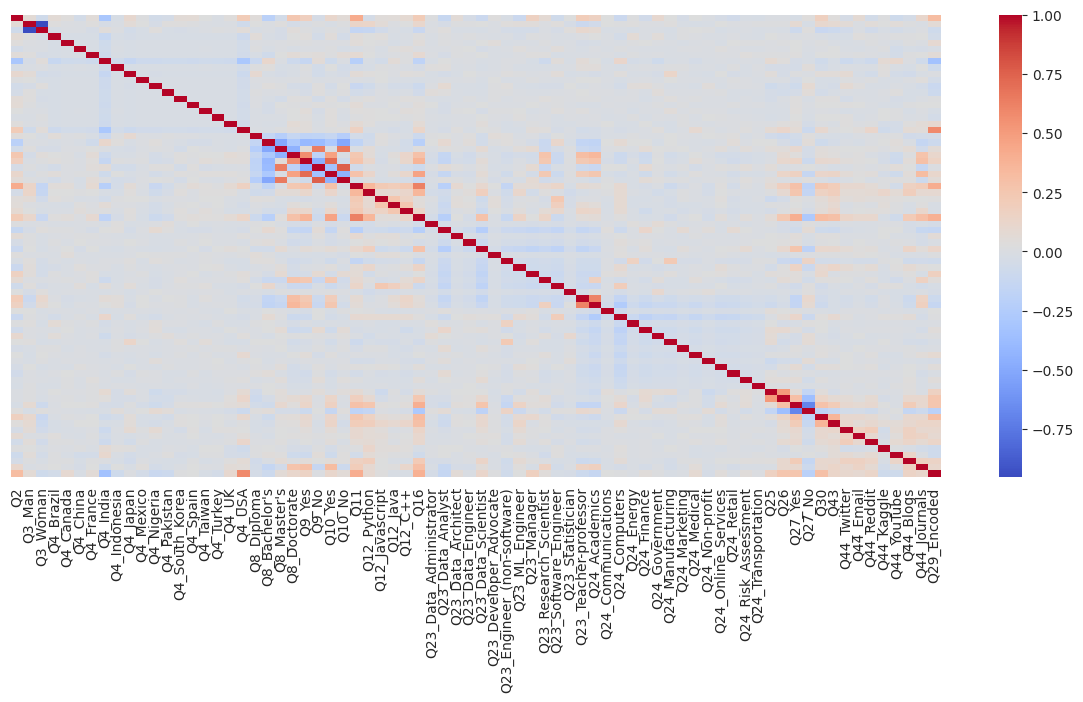

In [127]:
fig, ax = plt.subplots(figsize=(15,6))
cor = df.corr()
ax = sns.heatmap(cor, cmap='coolwarm', xticklabels=1, yticklabels=False)
plt.show()

Now, we sort the values and keep the features that have a correlation greater than 0.05 with Q29. The features are sorted in ascending order:

In [128]:
features_reduced = list(cor[cor['Q29_Encoded'] > 0.05].sort_values(by=['Q29_Encoded']).index)
features_reduced = features_reduced[:-1]
print(features_reduced)

["Q8_Master's", 'Q10_No', 'Q23_Data_Architect', 'Q4_France', 'Q3_Man', 'Q24_Medical', 'Q12_Python', 'Q4_Canada', 'Q44_Email', 'Q4_UK', 'Q44_Twitter', 'Q44_Journals', 'Q10_Yes', 'Q8_Doctorate', 'Q23_Data_Scientist', 'Q43', 'Q44_Reddit', 'Q44_Blogs', 'Q9_Yes', 'Q25', 'Q23_Manager', 'Q26', 'Q27_Yes', 'Q30', 'Q2', 'Q16', 'Q11', 'Q4_USA']


In [129]:
n = len(features_reduced)
n

28

We may now reduce the number of features to **28**. The table below shows the first 10 largest values in descending order:

In [130]:
cor[features_reduced+Q29].nlargest(10, 'Q29_Encoded')

,Q8_Master's,Q10_No,Q23_Data_Architect,Q4_France,Q3_Man,Q24_Medical,Q12_Python,Q4_Canada,Q44_Email,Q4_UK,...,Q25,Q23_Manager,Q26,Q27_Yes,Q30,Q2,Q16,Q11,Q4_USA,Q29_Encoded
Q29_Encoded,0.055217,0.055509,0.056666,0.057839,0.064588,0.083779,0.086202,0.087918,0.091461,0.100424,...,0.165795,0.171816,0.255658,0.257190,0.297714,0.315786,0.389068,0.406780,0.584734,1.000000
Q4_USA,0.009651,0.031501,0.027637,-0.060519,-0.069540,0.091409,-0.018213,-0.055857,0.040006,-0.060967,...,0.076415,0.044265,0.116912,0.064005,0.096134,0.209050,0.126104,0.163139,1.000000,0.584734
Q11,0.000986,-0.026224,0.085494,0.080977,0.137725,0.006446,0.346351,0.053543,0.094819,0.072534,...,0.075264,0.068471,0.178513,0.284629,0.247747,0.413909,0.620655,1.000000,0.163139,0.406780
Q16,0.032294,-0.108399,0.019714,0.089046,0.110606,0.020775,0.354667,0.041147,0.102491,0.065689,...,0.055943,0.021379,0.243022,0.402539,0.324002,0.208736,1.000000,0.620655,0.126104,0.389068
Q2,-0.052214,0.057419,0.060743,0.049628,0.069208,0.017312,-0.040200,0.032181,0.074679,0.035764,...,-0.000891,0.163815,-0.004415,-0.021578,0.172366,1.000000,0.208736,0.413909,0.209050,0.315786
Q30,0.045159,-0.013351,0.027097,0.018093,0.106513,0.037885,0.161421,0.015951,0.095608,0.004704,...,0.042931,0.102218,0.127940,0.281194,1.000000,0.172366,0.324002,0.247747,0.096134,0.297714
Q27_Yes,0.094120,-0.006211,0.043202,0.031194,0.080420,0.016317,0.260488,0.019732,0.083001,0.040276,...,0.068878,0.043263,0.305962,1.000000,0.281194,-0.021578,0.402539,0.284629,0.064005,0.257190
Q26,0.040419,-0.000780,0.012399,0.011439,0.014780,0.010095,0.085723,0.010968,0.028571,0.035168,...,0.508547,0.028801,1.000000,0.305962,0.127940,-0.004415,0.243022,0.178513,0.116912,0.255658
Q23_Manager,0.078106,0.071967,-0.032063,0.027927,0.044630,0.006248,-0.054351,-0.006186,0.013159,0.010693,...,0.041916,1.000000,0.028801,0.043263,0.102218,0.163815,0.021379,0.068471,0.044265,0.171816
Q25,0.050512,0.045794,0.022265,0.010492,0.012488,0.010822,0.010592,0.002340,-0.005336,0.008455,...,1.000000,0.041916,0.508547,0.068878,0.042931,-0.000891,0.055943,0.075264,0.076415,0.165795


We also present the variations of correlation with respect to these features:

/tmp/ipykernel_916/1309500583.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features_reduced, rotation=90)


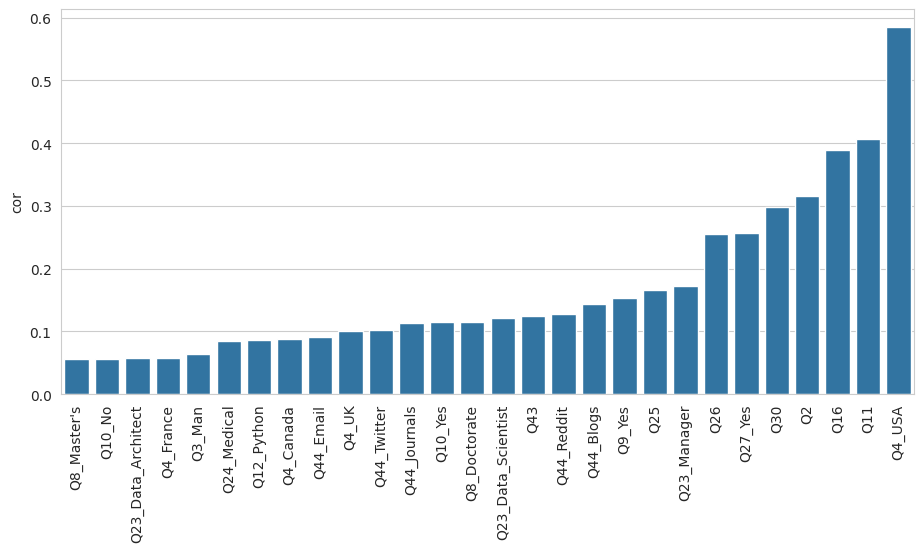

In [131]:
fig, ax = plt.subplots(figsize=(11,5))
data = pd.DataFrame(cor.loc[features_reduced, 'Q29_Encoded'].rename('cor'))
ax = sns.barplot(x=features_reduced, y='cor', data=data, color='tab:blue')
ax.set_xticklabels(features_reduced, rotation=90)
plt.show()

Interestingly, there is a high correlation between salary and participants from `'USA'`. There is also a high correlation between experience in coding and using ML methods (Q11 and Q16). Age (Q2), also seems to be an important features. These are all features that we expected to be of relevance to one's salary. Now that we have shown importance of different features using correlation, we may use the principal component analysis (PCA) to see what is the maximum total explained variance by 28 features. We note that we perform PCA on all features as this method entirely transforms the old features into new features in order to capture the highest variance:

In [132]:
# Standardizing the dataset:
data = df[features]
scaler = StandardScaler()
df_std = scaler.fit_transform(data)

# Performing PCA to capture 90% variance:
pca = PCA(0.8)

# Determining transformed features:
data = pca.fit_transform(df_std)

# Cumulative explained variance:
EV = pca.explained_variance_ratio_*100
CEV = np.cumsum(EV)

In [133]:
n = len(CEV)
n

45

The plot below shows the variations of cumulative explained variance (blue) and explained variance (red) with respect to number of components. Note that **45** principal components are required to explain 85% of total variance.

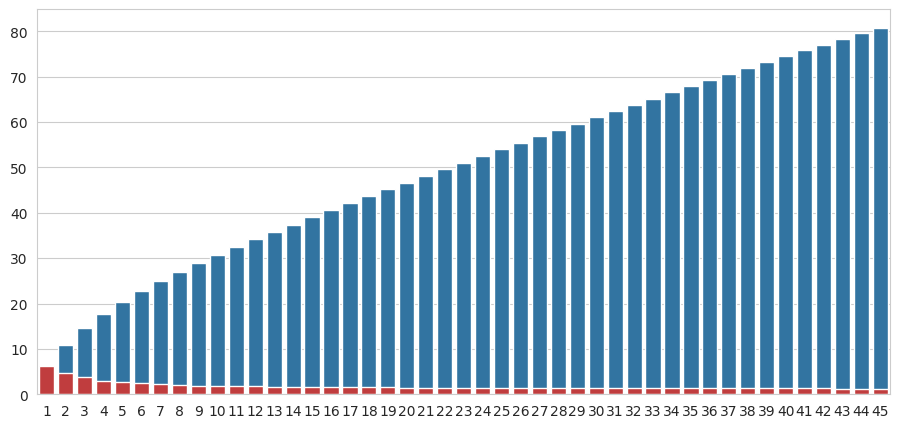

In [134]:
fig, ax = plt.subplots(figsize=(11,5))
ax = sns.barplot(x=[i for i in range(1, n+1)], y=CEV.tolist(), color='tab:blue')
ax = sns.barplot(x=[i for i in range(1, n+1)], y=EV.tolist(), color='tab:red')
plt.show()

As explained earlier, PCA completely changes our features into features that best explain the variance. It can be seen that the first 10 features are more important as they explain a higher percentage of variance. Other features are equivalently important as they have similar explained variance.

The above procedure was just to explain how PCA may be useful for feature engineering. For this Assignment, however, we will not use the features generated by PCA as we want to keep the original columns in the data. However, using only **28** features, at best we are only able to explain 58% of the total variance, as shown by the above plot.

In [135]:
df = df[features_reduced+Q29]
df.head()

,Q8_Master's,Q10_No,Q23_Data_Architect,Q4_France,Q3_Man,Q24_Medical,Q12_Python,Q4_Canada,Q44_Email,Q4_UK,...,Q25,Q23_Manager,Q26,Q27_Yes,Q30,Q2,Q16,Q11,Q4_USA,Q29_Encoded
0,False,0,False,True,True,False,1,False,0,False,...,0,False,1,True,3,8,2,5,False,2.0
1,False,0,False,False,True,False,1,False,1,False,...,2,False,6,True,0,3,5,5,False,10.0
2,False,0,False,False,True,False,1,False,1,False,...,3,False,6,True,2,10,6,6,False,10.0
3,False,0,False,False,True,False,1,False,1,False,...,3,False,6,True,2,5,6,5,True,13.0
4,True,0,False,False,True,False,1,False,0,False,...,3,False,2,True,5,5,6,5,True,13.0


## 5. Model Implementation

We implement an ordinal logistic regression algorithm on the training data using 10-fold cross-validation. We evaluate how the model accuracy compares across the folds and report the average and variance of accuracy. We treat each value of the hyper-parameter(s) as a separate model and identify the best-performing model. We provide reasoning for the model selection based on the bias-variance trade-off. The output of our algorithm includes the probability of belonging to each of the salary buckets. We apply scaling/normalization of features if necessary and justify whether scaling/normalization is required for the selected model.

If scaling/normalization is applied, we perform the transformation separately on the training and testing data to avoid data leakage.

We split the data into training and test data, where the training data contains at least 5000 samples.

In [136]:
X = df[features_reduced]
Y = df['Q29_Encoded']
nY = Y.nunique()

In [137]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=101)
train_idx = X_train.index

We have more than 5000 samples for training, as was requested by the assignment. Now, we perform ordinal logistic regression on the training set. Note that we also standardize the features to improve the convergence of the regression. Normalization is applied within the functions `OLR_Fit` and `OLR_Predict` **independently**.

In [138]:
def OLR_Fit(X_train, Y_train, model, nY):
    # Standardizing training features:
    X_train = scaler.fit_transform(X_train)

    nX = X_train.shape[1]
    idx = [i for i in range(nY-1)]

    dummies = ['Y'+str(i) for i in idx]
    Yd_train = pd.DataFrame(index=Y_train.index, columns=dummies)
    CumProb = pd.DataFrame(index=Y_train.index, columns=['Prob_'+i for i in dummies])
    columns = ['Prob_'+str(i) for i in range(nY)]
    Proba = pd.DataFrame(index=Y_train.index, columns=columns)
    coef_ = np.zeros((nY-1, nX))
    intercept_ = np.zeros((nY-1, 1))

    # Separating target variable into dummy columns:
    for i in idx:
        Yd_train.iloc[:, i] = Y_train.apply(lambda x: x <= idx[i]).astype(int)

    # Performing ordinal logistic regression:
    for i in idx:
        model.fit(X_train, Yd_train.iloc[:, i].astype(float).astype(int))
        CumProb.iloc[:, i] = model.predict_proba(X_train)[:, 1]
        coef_[i, :] = model.coef_
        intercept_[i] = model.intercept_

    # Calculating probabilities:
    Proba.iloc[:, 0] = CumProb.iloc[:, 0]
    for i in idx[:-1]:
        Proba.iloc[:, i+1] = CumProb.iloc[:, i+1]-CumProb.iloc[:, i]
    Proba.iloc[:, nY-1] = 1-CumProb.iloc[:, nY-2]

    encs = idx+[nY-1]
    predictions = Proba.idxmax(axis='columns')
    mapping = dict(zip(columns, encs))
    predictions = predictions.replace(mapping).infer_objects(copy=False).values

    return predictions, CumProb, Proba, coef_, intercept_

In [139]:
model = LogisticRegression()
Y_train = pd.Series(Y_train).astype(int)
predictions, CumProb, Proba, coef_, intercept_ = OLR_Fit(X_train, Y_train, model, nY)

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values


Below is the table for cumulative probability:

In [140]:
CumProb.head()

,Prob_Y0,Prob_Y1,Prob_Y2,Prob_Y3,Prob_Y4,Prob_Y5,Prob_Y6,Prob_Y7,Prob_Y8,Prob_Y9,Prob_Y10,Prob_Y11,Prob_Y12,Prob_Y13
3901,0.840976,0.890975,0.929605,0.949394,0.965725,0.980153,0.981634,0.985673,0.989746,0.991613,0.993669,0.995826,0.996652,0.998485
2173,0.287026,0.457447,0.591194,0.67652,0.738712,0.77585,0.834449,0.89899,0.929073,0.952791,0.978808,0.983515,0.989819,0.994424
1483,0.464831,0.65658,0.774512,0.849751,0.894101,0.918978,0.939751,0.954847,0.967511,0.97341,0.989149,0.990727,0.992708,0.994356
6467,0.258228,0.356205,0.434615,0.527546,0.672628,0.759901,0.795319,0.844327,0.877847,0.908325,0.943273,0.960677,0.976254,0.991678
3775,0.487684,0.655493,0.792596,0.849357,0.913977,0.944926,0.959812,0.973056,0.980109,0.987797,0.994213,0.995723,0.997154,0.99834


Finally, we have the probability of belonging to each of the salary buckets:

In [141]:
Proba.head()

,Prob_0,Prob_1,Prob_2,Prob_3,Prob_4,Prob_5,Prob_6,Prob_7,Prob_8,Prob_9,Prob_10,Prob_11,Prob_12,Prob_13,Prob_14
3901,0.840976,0.049999,0.03863,0.019789,0.016331,0.014427,0.001481,0.00404,0.004072,0.001868,0.002055,0.002157,0.000826,0.001833,0.001515
2173,0.287026,0.17042,0.133748,0.085325,0.062193,0.037137,0.0586,0.064541,0.030083,0.023718,0.026017,0.004707,0.006304,0.004604,0.005576
1483,0.464831,0.191749,0.117931,0.07524,0.04435,0.024877,0.020772,0.015096,0.012664,0.005899,0.015739,0.001578,0.001981,0.001648,0.005644
6467,0.258228,0.097977,0.07841,0.092931,0.145082,0.087272,0.035419,0.049007,0.03352,0.030478,0.034948,0.017404,0.015577,0.015424,0.008322
3775,0.487684,0.167809,0.137103,0.056761,0.06462,0.030949,0.014886,0.013244,0.007053,0.007688,0.006416,0.00151,0.001431,0.001186,0.00166


We define `OLR_Predict` function below. Note that this function predicts the same values for probability when applied to the training set. Our purpose for defining this function was to apply it to the test. The probability is obtained using the following equation:

\begin{equation}
p(x) = \frac{{{e^{{\beta _0} + {\beta _1}{x_1} +  \cdots  + {\beta _p}{x_p}}}}}{{1 + {e^{{\beta _0} + {\beta _1}{x_1} +  \cdots  + {\beta _p}{x_p}}}}}
\end{equation}

where $β_0$ is `intercept_`, $β_i$ are `coef_`, and $x_i$ are features.

In [142]:
def OLR_Predict(X_test, Y_test, coef_, intercept_, nY):
    X_test = scaler.fit_transform(X_test)
    nX = X_test.shape[1]
    nY = 15
    idx = [i for i in range(nY-1)]

    columns = ['Prob_'+str(i) for i in range(nY)]
    dummies = ['Y'+str(i) for i in idx]
    Yd_test = pd.DataFrame(index=Y_test.index, columns=dummies)
    CumProb = pd.DataFrame(index=Y_test.index, columns=['Prob_'+i for i in dummies])
    columns = ['Prob_'+str(i) for i in range(nY)]
    Proba = pd.DataFrame(index=Y_test.index, columns=columns)

    coef_ = np.transpose(coef_)
    intercept_ = np.transpose(intercept_)
    k = np.matmul(X_test, coef_)+intercept_[0, :]

    # Calculating cumulative probability:
    for i in idx:
        CumProb.iloc[:, i] = np.exp(k[:, i])/(1+np.exp(k[:, i]))

    # Calculating probabilities:
    Proba.iloc[:, 0] = CumProb.iloc[:, 0]
    for i in idx[:-1]:
        Proba.iloc[:, i+1] = CumProb.iloc[:, i+1]-CumProb.iloc[:, i]
    Proba.iloc[:, nY-1] = 1-CumProb.iloc[:, nY-2]

    encs = idx+[nY-1]
    predictions = Proba.idxmax(axis='columns')
    mapping = dict(zip(columns, encs))
    predictions = predictions.replace(mapping).values

    return predictions, CumProb, Proba

Uncomment the code below if you need to check `OLR_Predict` results.

In [143]:
predictions, CumProb, Proba = OLR_Predict(X_train, Y_train, coef_, intercept_, nY)
Proba.head()

/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values


,Prob_0,Prob_1,Prob_2,Prob_3,Prob_4,Prob_5,Prob_6,Prob_7,Prob_8,Prob_9,Prob_10,Prob_11,Prob_12,Prob_13,Prob_14
3901,0.840976,0.049999,0.03863,0.019789,0.016331,0.014427,0.001481,0.00404,0.004072,0.001868,0.002055,0.002157,0.000826,0.001833,0.001515
2173,0.287026,0.17042,0.133748,0.085325,0.062193,0.037137,0.0586,0.064541,0.030083,0.023718,0.026017,0.004707,0.006304,0.004604,0.005576
1483,0.464831,0.191749,0.117931,0.07524,0.04435,0.024877,0.020772,0.015096,0.012664,0.005899,0.015739,0.001578,0.001981,0.001648,0.005644
6467,0.258228,0.097977,0.07841,0.092931,0.145082,0.087272,0.035419,0.049007,0.03352,0.030478,0.034948,0.017404,0.015577,0.015424,0.008322
3775,0.487684,0.167809,0.137103,0.056761,0.06462,0.030949,0.014886,0.013244,0.007053,0.007688,0.006416,0.00151,0.001431,0.001186,0.00166


Now, we apply 10-fold cross-validation to evaluate model accuracy across the folds. **The test set is reserved for prediction and is not used here.** Please note the difference between lowercase and uppercase variables. For 10-fold cross-validation, lowercase variables are used to denote training and test sets.

In [144]:
def bais2(yp, y):
    power = np.power((yp-y), 2)
    return np.mean(power)

In [145]:
# Accuracy and 10-fold cross-validation:
model = LogisticRegression()
kfold = KFold(n_splits=10)
kfold.get_n_splits(X_train)

accuracy = np.zeros(10)
bias = np.zeros(10)
var = np.zeros(10)
idx = 0

for train_idx, test_idx in kfold.split(X_train):
    t = X_train.iloc[train_idx, :]

In [146]:
# Accuracy and 10-fold cross-validation:
model = LogisticRegression()
kfold = KFold(n_splits=10)
kfold.get_n_splits(X_train)

accuracy = np.zeros(10)
bias = np.zeros(10)
var = np.zeros(10)
idx = 0

for train_idx, test_idx in kfold.split(X_train):
    x_train, x_test = X_train.iloc[train_idx, :], X_train.iloc[test_idx, :]
    y_train, y_test = Y_train.iloc[train_idx] , Y_train.iloc[test_idx]

    predictions, CumProb, Proba, coef_, intercept_ = OLR_Fit(x_train, y_train, model, nY)
    predictions, CumProb, Proba = OLR_Predict(x_test, y_test, coef_, intercept_, nY)

    ACC = accuracy_score(y_test, predictions)*100
    accuracy[idx] = ACC
    bias[idx] = bais2(predictions, y_test)
    var[idx] = np.var(predictions)

    print("Fold %d: Accuracy: %.2f %%" % (idx, ACC))
    idx += 1

print("Mean Score: %.2f %%\nSTD: %.2f %%" % (np.mean(accuracy), np.var(accuracy)))

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values


Fold 0: Accuracy: 37.54 %


/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values


Fold 1: Accuracy: 37.54 %


/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future 

...

Fold 5: Accuracy: 42.18 %
Fold 6: Accuracy: 40.95 %


/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future b

Fold 7: Accuracy: 39.89 %
Fold 8: Accuracy: 40.42 %


/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future 

Fold 9: Accuracy: 39.02 %
Mean Score: 39.69 %
STD: 6.02 %


The highest accuracy belongs to the **4th fold** with 45.09% accuracy. The average and variance of accuracy are 39.69% and 6.02%, respectively.

In [147]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1,\
                        train_sizes=np.linspace(.1, 1.0, 5), scoring='accuracy'):

    plt.figure(figsize=(10,6))
    plt.title(title)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Training examples")
    plt.ylabel(scoring)

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,\
                     train_scores_mean + train_scores_std, alpha=0.1, \
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,\
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")

    return plt

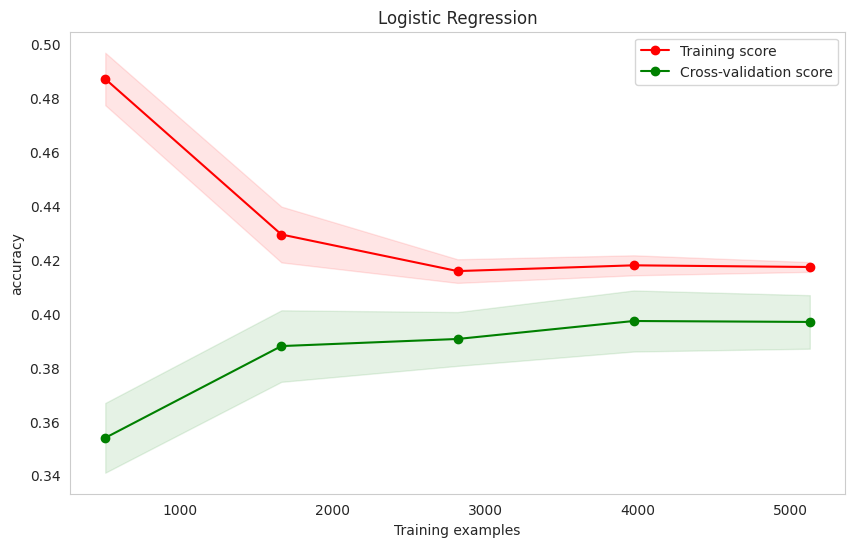

In [148]:
plot_learning_curve(model,'Logistic Regression', scaler.fit_transform(X_train), Y_train, cv=10)
plt.show()

The table below shows bias and variance accross folds:

In [149]:
pd.DataFrame({'Bias': bias, 'Variance': var})

,Bias,Variance
0,14.887719,19.367670
1,14.545614,20.269563
2,13.673684,20.336907
3,12.247368,20.495417
4,16.833040,20.148029
5,13.525483,19.336467
6,14.237258,20.815435
7,12.107206,19.535929
8,13.492091,19.564568
9,16.908612,19.266354


In [150]:
print('Bias: %.2f' % np.mean(bias))
print('Variance: %.2f' % np.mean(var))

Bias: 14.25
Variance: 19.91


Next, we choose **penalty** and **C** as hyper-parameters for this part. The list of all hyper-parameters is presented in section 6. For now, we fix the solver at **lbfgs** which only supports `'l2'` or `'none'` penalties.

In [151]:
C_list = [0.001, 0.01, 0.1, 10, 100, 1000]

n = len(C_list)
bias = np.zeros(n)
var = np.zeros(n)
idx = 0

for C in C_list:
    model = LogisticRegression(C=C, max_iter=10000)

    # Fitting training data:
    predictions, CumProb, Proba, coef_, intercept_ = OLR_Fit(X_train, Y_train, model, nY)

    bias[idx] = bais2(predictions, Y_train)
    var[idx] = np.var(predictions)
    idx += 1
pd.DataFrame(index=C_list, columns=['Bias', 'Variance'], data=list(zip(bias, var)))

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

,Bias,Variance
0.001,22.224798,11.308863
0.010,15.167896,18.866246
0.100,14.224096,20.030928
10.000,14.046189,20.157972
100.000,14.046189,20.157972
1000.000,14.046189,20.157972


In [152]:
penalty_list = [None, 'l2']

n = len(penalty_list)
bias = np.zeros(n)
var = np.zeros(n)
idx = 0

for penalty in penalty_list:
    model = LogisticRegression(penalty=penalty)

    # Fitting training data:
    predictions, CumProb, Proba, coef_, intercept_ = OLR_Fit(X_train, Y_train, model, nY)

    bias[idx] = bais2(predictions, Y_train)
    var[idx] = np.var(predictions)
    idx += 1
pd.DataFrame(index=penalty_list, columns=['Bias', 'Variance'], data=list(zip(bias, var)))

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values


,Bias,Variance
None,14.046189,20.157972
l2,14.046365,20.153427


For our model, the bias is lower than variance. Still, as we will see later, the bias is still quit high and we must increase the model complexity to increase the accuracy of predictions.

## 6. Model Tuning

We identify all the hyper-parameters in our model. We select two hyper-parameters for model tuning and justify our selection. We improve the performance of the models from the previous step through hyper-parameter tuning and select a final optimal model using grid search based on the metric(s) that we choose. Selecting an optimal model for a given task requires choosing appropriate performance measures, such as accuracy, precision, recall, and/or F1-score, to compare model performance. We explain why accuracy may not be a suitable performance metric for this problem. There is no minimum model performance requirement, as long as our methodology is reasonable and well explained.

We create the feature importance graph of our model to identify which features have the greatest influence on model predictions. We compare this graph with the feature importance graph obtained in Section 4.

The hyper-parameters for logistic regression are as follows:
- **solver** in `['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']`.
- **penalty** in `['none', 'l1', 'l2', 'elasticnet']`. Note that not all solvers support all regularization terms.
- **dual** in `[False, True]`.
- **tol** which is the tolerance for stopping criteria.
- **C** parameter which controls the penalty strength.
- **fit_intercept** which determines whether the intercept_ is fitted or not.

In the next parts, we use grid search to find the best **solver** and **C** for our model.

## 7. Grid search

We apply Grid searching to select hyper-parameters that optimize the model. Grid search builds several models with all the parameter combinations specified, and runs cross validation to return the set of parameters that had the highest cv score on the validation set.

We emphasize that accuracy is not a good metric for classification problems. Imbalanced data refers to a data set where the distribution of instances across the classes is biased. Machine learning models tend to classify larger classes and ignore the smaller ones since classifying the data in larger classes will get them to a higher accuracy more quickly. Hence, for classification problems, we may also consider **confusion matrix** which reveals more information about the underlying classes. In this assignment, we will use the **confusion matrix** when we apply the **Grid search**.

We plot the histogram of salary buckets to check the data balance. As we can see, the `0` bucket constitutes a higher number of instances, and consequently, the data is not balanced. Hence, it makes sense to use the confusion matrix to evaluate the model performance.

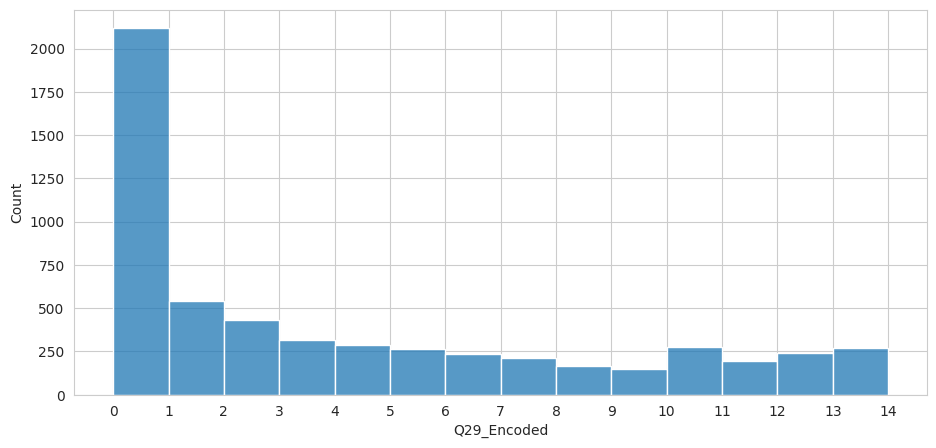

In [153]:
fig, ax = plt.subplots(figsize=(11,5))
ax = sns.histplot(Y_train, binwidth=1, color='tab:blue')
plt.xticks([i for i in range(nY)])
plt.show()

In [154]:
model = LogisticRegression()
scaler = StandardScaler()
kfold = KFold(n_splits=10)
kfold.get_n_splits(X)

best_model = model
best_params = {}
best_metric = 0
best_std = 0

for C in [0.001, 0.01, 0.1, 1.0, 10]:
    for solver in ['newton-cg','lbfgs','liblinear','sag']:

        model = LogisticRegression(C=C, solver=solver, max_iter=10000)
        accuracy = np.zeros(10)
        score = np.zeros(10)
        idx = 0

        for train_idx, test_idx in kfold.split(X_train):
            x_train, x_test = X_train.iloc[train_idx, :], X_train.iloc[test_idx, :]
            y_train, y_test = Y_train.iloc[train_idx] , Y_train.iloc[test_idx]

            predictions, CumProb, Proba, coef_, intercept_ = OLR_Fit(x_train, y_train, model, nY)
            predictions, CumProb, Proba = OLR_Predict(x_test, y_test, coef_, intercept_, nY)

            y_test = y_test.values
            TN = confusion_matrix(y_test, predictions)[0][0]
            FP = confusion_matrix(y_test, predictions)[0][1]
            FN = confusion_matrix(y_test, predictions)[1][0]
            TP = confusion_matrix(y_test, predictions)[1][1]
            total = TN+FP+FN+TP
            ACC = (TP+TN)/float(total)

            accuracy[idx] = ACC*100
            score[idx] = accuracy_score(y_test, predictions)*100

            idx += 1

        metric = score
        if np.mean(metric) > best_metric:
            best_model = model
            best_params = {'C':C, 'solver':solver}
            best_metric = np.mean(metric)
            best_std = np.std(metric)

print (best_params)
print ("Best Score: {}%({}%)".format(round(best_metric, 3), round(best_std, 3)))
print ("\nThe optimal log model uses C={}, and a {} solver, and has an accuracy of {}% with a standard deviation of {}%.".format(best_params['C'], best_params['solver'], round(best_metric, 3), round(best_std, 3)))

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values
/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future 

{'C': 0.01, 'solver': 'liblinear'}
Best Score: 40.376%(2.835%)

The optimal log model uses C=0.01, and a liblinear solver, and has an accuracy of 40.376% with a standard deviation of 2.835%.


/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values


In [155]:
model = LogisticRegression(C=best_params['C'], solver=best_params['solver'])
predict_train, CumProb, Proba, coef_, intercept_ = OLR_Fit(X_train, Y_train, model, nY)

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values


Feature importance in logistic regression depends on the coefficients obtained during the training phase. For our model, these coefficients are as follows:

In [156]:
pd.DataFrame(np.abs(coef_), columns=features_reduced).head()

,Q8_Master's,Q10_No,Q23_Data_Architect,Q4_France,Q3_Man,Q24_Medical,Q12_Python,Q4_Canada,Q44_Email,Q4_UK,...,Q9_Yes,Q25,Q23_Manager,Q26,Q27_Yes,Q30,Q2,Q16,Q11,Q4_USA
0,0.042584,0.061394,0.021825,0.149870,0.147627,0.073107,0.079257,0.187317,0.016371,0.269164,...,0.082899,0.235815,0.209422,0.185643,0.150214,0.191103,0.339504,0.258887,0.355583,0.730510
1,0.039318,0.057545,0.016588,0.190379,0.160398,0.070799,0.115573,0.223748,0.006995,0.323263,...,0.095589,0.198831,0.244745,0.174077,0.170909,0.203014,0.379050,0.287283,0.358956,0.889337
2,0.036280,0.058399,0.040607,0.187211,0.145874,0.104233,0.101485,0.241086,0.022159,0.341054,...,0.101524,0.188855,0.225657,0.176554,0.199192,0.243514,0.369339,0.310218,0.320744,1.003438
3,0.023993,0.073150,0.046584,0.177801,0.123112,0.101658,0.093180,0.247370,0.061772,0.296543,...,0.104798,0.157306,0.207281,0.172792,0.175892,0.219146,0.333391,0.323712,0.313998,1.041462
4,0.037233,0.099731,0.048391,0.145072,0.094918,0.089271,0.108295,0.238370,0.044441,0.263257,...,0.091089,0.160302,0.210406,0.123646,0.187263,0.231616,0.328943,0.300327,0.300966,1.055107


For instance, let's plot the importance of features for `0` bucket:

In [157]:
imp = np.abs(coef_[0, :]).tolist()
features_imp = [i for _,i in sorted(zip(imp, features_reduced))]
imp.sort()

/tmp/ipykernel_916/759616889.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features_imp, rotation=90)


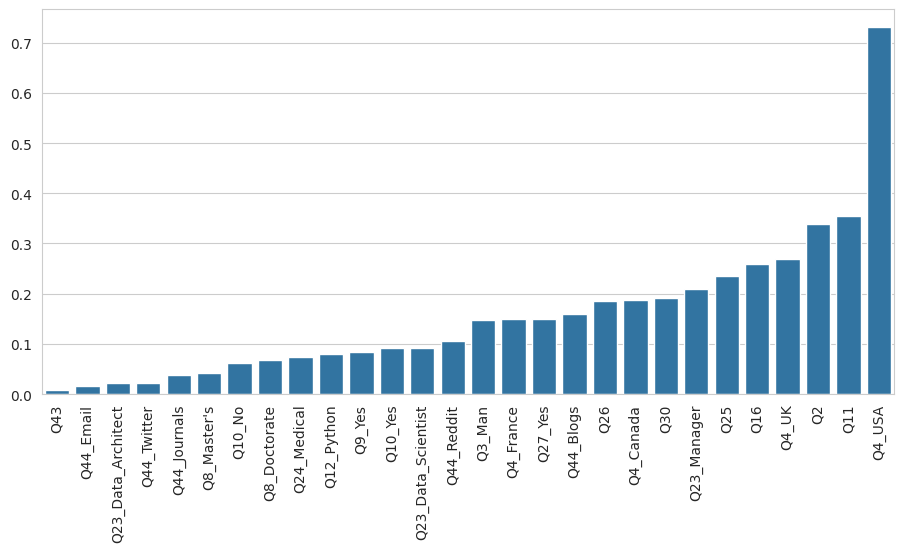

In [158]:
fig, ax = plt.subplots(figsize=(11,5))
ax = sns.barplot(x=features_imp, y=imp, color='tab:blue')
ax.set_xticklabels(features_imp, rotation=90)
plt.show()

Evidently, this plot is not significantly different from the one provided using correlation analysis. Some similarities and differences include:
- `'Q4_USA'`, `'Q11'`, `'Q16'`, and `'Q2'` are still significantly important.
- `'Q44_Journals'` and `'Q44_Twitter'` are far less important.
- `'Q3_Man'` is far more important.

In [159]:
imp = np.abs(np.average(coef_, axis=0)).tolist()
features_imp = [i for _,i in sorted(zip(imp, features_reduced))]
imp.sort()

below is the plot of importance based on the average of coefficients over buckets:

/tmp/ipykernel_916/2625321168.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(features_imp, rotation=90)


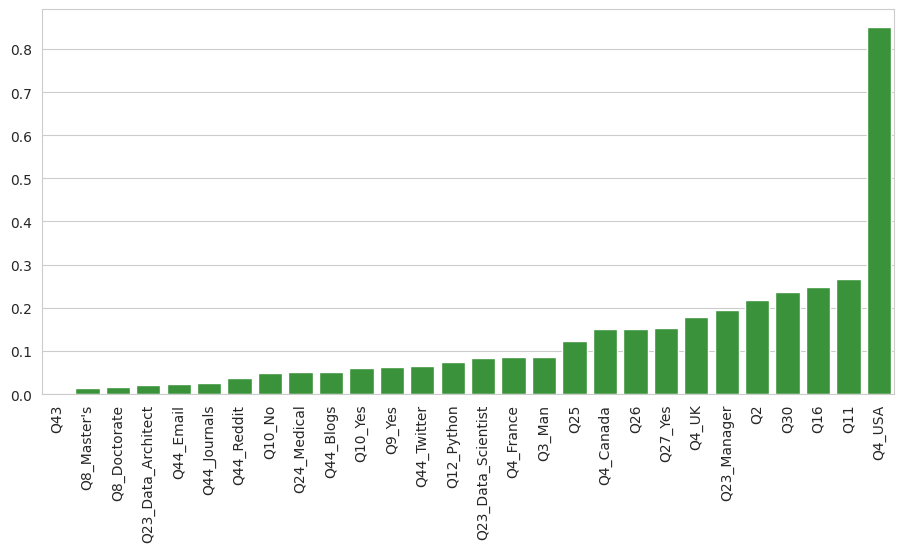

In [160]:
fig, ax = plt.subplots(figsize=(11,5))
ax = sns.barplot(x=features_imp, y=imp, color='tab:green')
ax.set_xticklabels(features_imp, rotation=90)
plt.show()

## Testing and Discussion

We use our optimal model to make classifications on the test set. We ensure that the test set is not used in any form during the training process, including as a validation set. We evaluate how our model performs on the test set compared with the training set. We analyze the overall fit of the model and discuss possible approaches to improve the performance on both the test and training sets. We determine whether the model is overfitting or underfitting and provide reasoning for our conclusion.

We plot the distribution of the true target variable values and their predictions on both the training and test sets. Finally, we discuss the insights gained from the dataset and our trained classification model.

In the previous part we were able to obtain the optimal hyper-parameters and tune our model. Now we train the model with optimal parameters on the entire training set and use it to make predictions on our unlabeled set. Note that we have not used the test set during the training phase, as we split the training data for cross-validation.

In [161]:
model = LogisticRegression(C=best_params['C'], solver=best_params['solver'])
scaler = StandardScaler()

predict_train, CumProb, Proba, coef_, intercept_ = OLR_Fit(X_train, Y_train, model, nY)
predict_test, CumProb, Proba = OLR_Predict(X_test, Y_test, coef_, intercept_, nY)

predict_train = pd.DataFrame(predict_train, index=Y_train.index, columns=['Q29_Predict'])
predict_test = pd.DataFrame(predict_test, index=Y_test.index, columns=['Q29_Predict'])

/tmp/ipykernel_916/3375329729.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).infer_objects(copy=False).values
/tmp/ipykernel_916/276735646.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictions = predictions.replace(mapping).values


In [162]:
predict_test.head()

,Q29_Predict
1433,0
3308,0
6626,0
250,0
7244,0


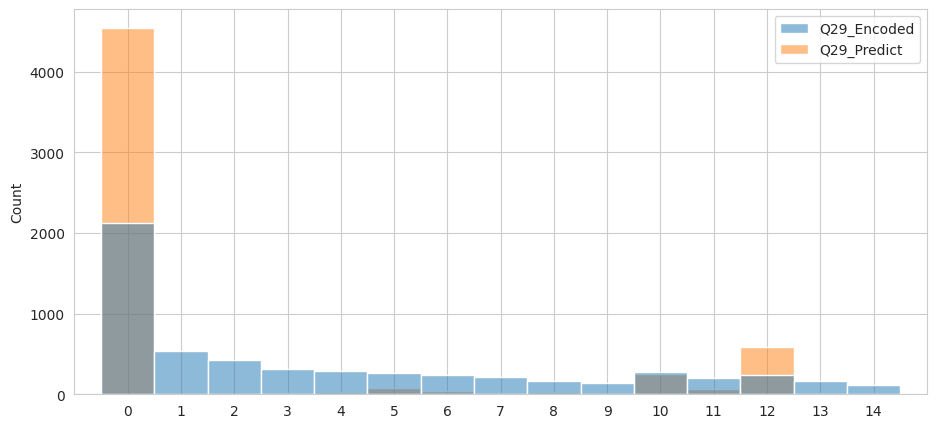

In [163]:
fig, ax = plt.subplots(figsize=(11,5))
data = pd.concat([Y_train, predict_train], axis=1, join='inner')
ax = sns.histplot(data, binrange=(-0.5, 14.5), binwidth=1, color='tab10')
plt.xlim(-1.0, nY)
plt.xticks([i for i in range(nY)])
plt.show()

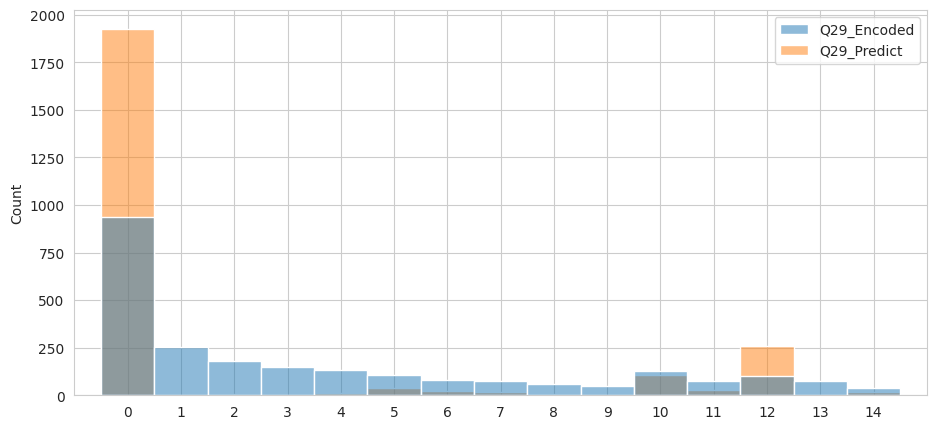

In [164]:
fig, ax = plt.subplots(figsize=(11,5))
data = pd.concat([Y_test, predict_test], axis=1, join='inner')
ax = sns.histplot(data, binrange=(-0.5, 14.5), binwidth=1, color='tab10')
plt.xlim(-1.0, nY)
plt.xticks([i for i in range(nY)])
plt.show()

For our model, the performance on the test and training sets is not really different, as was shown in the above plots. Using confusion matrix, the model only predicted `0`, which is a majority class, and `14` buckets, and absolutely no other salary buckets. `0` bucket is not of importance as we like to be able to accurately predict higher salary buckets based on our features. Not being able to accurately predict minority classes makes the model **under-fitted**. As discussed in bias-variance trade-off analysis, a higher `C` tends to decrease the bias. The optimum `C` using accuracy was 0.01, whereas the optimum `C` using confusion matrix was 0.001. This argument is also in favor of choosing accuracy over confusion matrix for the current model. Note that we also used other metrics, such as precision, to obtain the best parameters. Overall, these metrics had no advantage over accuracy score as the model was still biased toward majority classes and could not predict any other salary buckets.

Using the accuracy score, the model made far more correct predictions, particularly in`5`, `10`, `12`, and `14` buckets. even though there were still several incorrect predictions in `0` bucket.

Our results show that our model is under-fitted and we must increase our model complexity. One way to do this is to include some of the features that we dropped during feature selection and redo the feature selection phase. We can also increase the training sample size for the minority classes and make the training set more balanced. Another solution is to use non-linear classification algorithms, such as decision tree model, random forest, or neural networks.

- **Accuracy**: refers to the total number of correct predictions over the total number of predictions.
- **Precision**: refers to the total number of true positive predictions over the total number of datapoints predicted as positive.
- **Recall or Sensitivity**: refers to the total number true positive predictions over total the number of all datapoints with actual positive labels.
- **Specificity**: refers to the total number of true negative predictions over the total number of all datapoints with actual negative labels.
- **F1-score**: refers to the harmonic mean of precision and recall.